# Stock Market Analysis — Solution Notebook

**Dataset:** `stock_prices_2026.csv` — 750 rows of synthetic daily stock prices.

| Column | Meaning |
|---|---|
| `Date` | Trading day (business days only) |
| `Ticker` | Stock symbol |
| `Company` | Full company name |
| `Sector` | Business sector |
| `Open / High / Low / Close` | Prices in USD |
| `Volume` | Shares traded that day |

**The market:** 5 fictional companies × 150 trading days (Jan 5 – Jul 31, 2026):

- **TECHX** — NovaTech Systems (Technology)
- **BANKY** — Meridian Bank Corp (Finance)
- **MEDIX** — CarePoint Health (Healthcare)
- **RETAIL** — ShopMart Retail Group (Consumer)
- **OILCO** — PetroGulf Energy (Energy)

Every exercise below matches the numbered questions in the exercise sheet.

## Setup

We import the libraries we need. We only use **beginner-level tools**:
plain `for` loops, simple functions, and basic pandas/matplotlib calls.
No lambdas, no `.apply()`, no iterators.

In [2]:
import math

import matplotlib.pyplot as plt
import pandas as pd

Load the CSV file. `parse_dates=["Date"]` converts the Date column from plain
text into real dates, which lets us sort and group by time later.

In [3]:
# Path to the dataset (change this if your file lives somewhere else)
CSV_PATH = "/Users/ahmad/Desktop/stock_prices_2026.csv"

# Read the CSV into a DataFrame
df = pd.read_csv(CSV_PATH, parse_dates=["Date"])

# Fixed order of tickers, so tables and charts always look consistent
TICKERS = ["BANKY", "MEDIX", "OILCO", "RETAIL", "TECHX"]

df.head()

,Date,Ticker,Company,Sector,Open,High,Low,Close,Volume
0,2026-01-05,BANKY,Meridian Bank Corp,Finance,92.16,94.29,91.81,93.81,4786875
1,2026-01-05,MEDIX,CarePoint Health,Healthcare,143.30,143.81,139.97,140.90,2955333
2,2026-01-05,OILCO,PetroGulf Energy,Energy,117.53,120.11,116.38,119.72,6640273
3,2026-01-05,RETAIL,ShopMart Retail Group,Consumer,68.00,68.43,66.69,66.75,2190160
4,2026-01-05,TECHX,NovaTech Systems,Technology,183.72,187.83,181.99,186.43,4142385


## The Analyzer Class

All solution logic lives inside one class: `StockAnalyzer`.

- `__init__` stores the DataFrame and prepares empty helper columns
- Every **exercise question gets its own method**
- Methods that need calculated columns (like `Daily_Return`) build them
  step by step with a plain `for` loop over tickers

Run this cell once before any question below.

In [4]:
class StockAnalyzer:

    def __init__(self, dataframe):
        # Store the data inside the object so every method can reach it
        self.df = dataframe
        self.returns_matrix = None  # filled later by get_returns_matrix()

    # ================= PART A : EXPLORATION =================

    def explore(self):
        """Q1-Q3: shape, dtypes, unique counts."""
        print("First 5 rows:")
        print(self.df.head())
        print("\nLast 5 rows:")
        print(self.df.tail())
        print("\nShape (rows, columns):", self.df.shape)
        print("\nColumn types:")
        print(self.df.dtypes)
        print("\nUnique tickers:", self.df["Ticker"].nunique())
        print("Unique trading days:", self.df["Date"].nunique())

    def rows_per_ticker(self):
        """Q2: check every ticker has exactly 150 rows."""
        print(self.df.groupby("Ticker").size())

    def describe_numbers(self):
        """Q3: quick statistics for all numeric columns."""
        print(self.df.describe().round(2))

    def highest_avg_price(self):
        """Q3b: stock with the highest average closing price."""
        avg_prices = self.df.groupby("Ticker")["Close"].mean().sort_values(ascending=False)
        print(avg_prices.round(2))
        print("\nHighest average closing price:", avg_prices.index[0])

    def show_stock(self, ticker):
        """Q4: filter the table down to one ticker."""
        sub = self.df[self.df["Ticker"] == ticker]
        return sub

    # ================= PART B : GROUPBY & AGGREGATION =================

    def price_summary(self):
        """Q5: average close + highest high, per ticker."""
        avg_close = self.df.groupby("Ticker")["Close"].mean()
        max_high = self.df.groupby("Ticker")["High"].max()
        print("Average closing price:")
        print(avg_close.round(2))
        print("\nHighest price ever reached:")
        print(max_high)

    def sector_volume(self):
        """Q6: total traded volume per sector."""
        totals = self.df.groupby("Sector")["Volume"].sum().sort_values(ascending=False)
        print(totals)
        print("\nMost active sector:", totals.index[0])

    def biggest_volume_day(self):
        """Q7: the single largest-volume day in the whole dataset."""
        row_index = self.df["Volume"].idxmax()
        return self.df.loc[row_index]

    def summary_table(self):
        """Q8: one summary row per ticker, built with a plain loop."""
        rows = []
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            info = {
                "Ticker": t,
                "First_Close": sub["Close"].iloc[0],
                "Last_Close": sub["Close"].iloc[-1],
                "Min_Low": sub["Low"].min(),
                "Max_High": sub["High"].max(),
                "Total_Volume": sub["Volume"].sum(),
            }
            rows.append(info)
        return pd.DataFrame(rows)

    def green_days(self):
        """Q9: count up-days vs down-days for each ticker."""
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            green = (sub["Close"] > sub["Close"].shift(1)).sum()  # shift(1) = previous day
            red = len(sub) - 1 - green                            # first day has no previous day
            print(t, "| green days:", int(green), "| red days:", int(red))

    # ================= PART C : RETURNS & TIME SERIES =================

    def add_daily_return(self):
        """Q10: % change of Close, computed separately per ticker."""
        parts = []
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            pct = sub["Close"].pct_change() * 100   # pct_change compares with the row above
            parts.append(pct)
        # concat puts the pieces back together in the original row order,
        # so every return lines up with its own stock (no mixing!)
        self.df["Daily_Return"] = pd.concat(parts)

    def rank_by_return(self):
        """Q11: rank stocks by average daily return."""
        averages = self.df.groupby("Ticker")["Daily_Return"].mean().sort_values(ascending=False)
        print(averages.round(4))

    def volatility_rank(self):
        """Q12: standard deviation of daily returns = risk."""
        stds = self.df.groupby("Ticker")["Daily_Return"].std().sort_values(ascending=False)
        print(stds.round(3))
        print("\nRisky stock:", stds.index[0])
        print("Calmest stock:", stds.index[-1])

    def best_worst_days(self):
        """Q13: best and worst day for every ticker."""
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            best_row = self.df.loc[sub["Daily_Return"].idxmax()]
            worst_row = self.df.loc[sub["Daily_Return"].idxmin()]
            print(t,
                  "| BEST :", best_row["Date"].date(), round(best_row["Daily_Return"], 2), "%",
                  "| WORST:", worst_row["Date"].date(), round(worst_row["Daily_Return"], 2), "%")

    def monthly_stats(self):
        """Q14: monthly averages and volumes, grouped by month name."""
        # strftime("%Y-%m") turns a date like 2026-03-17 into the text "2026-03"
        self.df["Month"] = self.df["Date"].dt.strftime("%Y-%m")
        avg_close = self.df.groupby(["Ticker", "Month"])["Close"].mean().round(2)
        total_volume = self.df.groupby(["Ticker", "Month"])["Volume"].sum()
        print("Monthly average close:")
        print(avg_close)
        print("\nMonthly total volume:")
        print(total_volume)

    def add_rolling_mean(self):
        """Q15: 20-day moving average + a True/False trend column."""
        means = []
        signals = []
        window = 20
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            ma = sub["Close"].rolling(window=window).mean()   # average of the last 20 closes
            means.append(ma)
            signals.append(sub["Close"] > ma)
        self.df["MA20"] = pd.concat(means)
        self.df["Above_MA20"] = pd.concat(signals)

    def above_ma20_count(self):
        """Q16: how often TECHX finished above its own MA20."""
        techx = self.df[self.df["Ticker"] == "TECHX"]
        above = int(techx["Above_MA20"].sum())
        total = int(techx["Above_MA20"].count())
        print("TECHX closed above MA20 on", above, "of", total, "days")

    # ================= PART D : FILTERING & LOGIC =================

    def big_moves(self):
        """Q17: every day where ANY stock jumped or dropped more than 3%."""
        movers = self.df[self.df["Daily_Return"].abs() > 3]
        return movers.sort_values("Date")[["Date", "Ticker", "Close", "Daily_Return"]].round(2)

    def volume_spikes(self):
        """Q18: compare moves on crazy-volume days vs normal days."""
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            avg_volume = sub["Volume"].mean()
            spikes = sub[sub["Volume"] > 2 * avg_volume]   # more than double normal volume
            normal = sub[sub["Volume"] <= 2 * avg_volume]
            spike_move = spikes["Daily_Return"].abs().mean()
            normal_move = normal["Daily_Return"].abs().mean()
            print(t,
                  "| spike days:", len(spikes),
                  "| avg move on spikes:", round(spike_move, 2), "%",
                  "| avg move normally:", round(normal_move, 2), "%")

    def ma20_signal_test(self):
        """Q19: does being above MA20 predict a good next day?"""
        parts = []
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            nxt = sub["Daily_Return"].shift(-1)   # shift(-1) pulls TOMORROW's return back here
            parts.append(nxt)
        self.df["Next_Return"] = pd.concat(parts)

        above = self.df[self.df["Above_MA20"]]
        below = self.df[self.df["Above_MA20"] == False]
        print("Avg next-day return ABOVE MA20:", round(above["Next_Return"].mean(), 3), "%")
        print("Avg next-day return BELOW MA20:", round(below["Next_Return"].mean(), 3), "%")

    # ================= PART E : CHARTS =================

    def plot_prices(self):
        """Q20: all five closing-price lines on one chart."""
        plt.figure(figsize=(12, 6))
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            plt.plot(sub["Date"], sub["Close"], label=t)
        plt.title("Closing Prices (Jan - Jul 2026)")
        plt.xlabel("Date")
        plt.ylabel("Price ($)")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_growth_of_100(self):
        """Q21: growth of $100 invested on day one (fair comparison)."""
        plt.figure(figsize=(12, 6))
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            growth = sub["Close"] / sub["Close"].iloc[0] * 100
            plt.plot(sub["Date"], growth, label=t)
        plt.axhline(y=100, color="gray", linestyle="--")   # break-even line
        plt.title("Growth of $100 Invested on Jan 5")
        plt.xlabel("Date")
        plt.ylabel("Value ($)")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_returns_histogram(self, ticker):
        """Q22: distribution of daily returns for one stock."""
        sub = self.df[self.df["Ticker"] == ticker]
        plt.figure(figsize=(10, 5))
        plt.hist(sub["Daily_Return"].dropna(), bins=30, color="steelblue", edgecolor="black")
        plt.title(ticker + " - Daily Returns Distribution")
        plt.xlabel("Daily Return (%)")
        plt.ylabel("Number of Days")
        plt.grid(True)
        plt.show()

    def plot_avg_volume(self):
        """Q23a: bar chart of average volume per stock."""
        avgs = self.df.groupby("Ticker")["Volume"].mean()
        plt.figure(figsize=(9, 5))
        plt.bar(avgs.index, avgs.values / 1e6, color="seagreen")   # divide to show millions
        plt.title("Average Daily Volume")
        plt.xlabel("Ticker")
        plt.ylabel("Millions of Shares")
        plt.grid(axis="y")
        plt.show()

    def plot_sector_volume(self):
        """Q23b: bar chart of total volume per sector."""
        totals = self.df.groupby("Sector")["Volume"].sum().sort_values(ascending=False)
        plt.figure(figsize=(9, 5))
        plt.bar(totals.index, totals.values / 1e9, color="darkorange")   # billions
        plt.title("Total Volume by Sector")
        plt.xlabel("Sector")
        plt.ylabel("Billions of Shares")
        plt.grid(axis="y")
        plt.show()

    def plot_returns_boxplot(self):
        """Q24: boxplot comparing return spreads of all stocks."""
        data = []
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            data.append(sub["Daily_Return"].dropna())
        plt.figure(figsize=(10, 6))
        plt.boxplot(data)
        # put ticker names under each box manually (works on every matplotlib version)
        positions = [1, 2, 3, 4, 5]
        plt.xticks(positions, TICKERS)
        plt.title("Spread of Daily Returns")
        plt.ylabel("Daily Return (%)")
        plt.grid(True)
        plt.show()

    def plot_volume_vs_move(self, ticker):
        """Q25: scatter of volume against size of the daily move."""
        sub = self.df[self.df["Ticker"] == ticker]
        plt.figure(figsize=(10, 6))
        plt.scatter(sub["Volume"] / 1e6, sub["Daily_Return"].abs(), alpha=0.6)
        plt.title(ticker + ": Volume vs |Daily Move|")
        plt.xlabel("Volume (millions)")
        plt.ylabel("| Daily Return | (%)")
        plt.grid(True)
        plt.show()

    def plot_subplot_grid(self):
        """Q26: 2x3 grid with one mini price chart per stock."""
        fig, axes = plt.subplots(2, 3, figsize=(16, 8))
        fig.suptitle("One Chart per Stock")
        index = 0
        for r in [0, 1]:
            for c in [0, 1, 2]:
                if index < len(TICKERS):
                    t = TICKERS[index]
                    sub = self.df[self.df["Ticker"] == t]
                    axes[r][c].plot(sub["Date"], sub["Close"])
                    axes[r][c].set_title(t)
                    axes[r][c].grid(True)
                    index = index + 1
        plt.tight_layout()
        plt.show()

    # ================= BONUS =================

    def max_drawdown_all(self):
        """Q27: worst peak-to-trough fall for each stock."""
        for t in TICKERS:
            sub = self.df[self.df["Ticker"] == t]
            running_max = sub["Close"].cummax()               # highest price seen so far
            drawdown = (sub["Close"] / running_max - 1) * 100  # % below that peak
            worst_value = drawdown.min()
            worst_day = sub.loc[drawdown.idxmin(), "Date"].date()
            print(t, "| max drawdown:", round(worst_value, 1), "% on", worst_day)

    def get_returns_matrix(self):
        """Helper: reshape prices into a wide table (one column per ticker)."""
        prices = self.df.pivot(index="Date", columns="Ticker", values="Close")
        self.returns_matrix = prices.pct_change()
        return self.returns_matrix

    def plot_correlation_heatmap(self):
        """Q28: 5x5 correlation matrix drawn with imshow()."""
        if self.returns_matrix is None:
            self.get_returns_matrix()
        corr = self.returns_matrix.corr()

        plt.figure(figsize=(7, 6))
        plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
        plt.colorbar(label="Correlation")

        positions = [0, 1, 2, 3, 4]
        plt.xticks(positions, corr.columns)
        plt.yticks(positions, corr.columns)

        # Write the number inside each square
        for i in positions:
            for j in positions:
                value = round(corr.iloc[i, j], 2)
                plt.text(j, i, str(value), ha="center", va="center", color="black")

        plt.title("Correlation of Daily Returns")
        plt.tight_layout()
        plt.show()

    def plot_oilco_dual_axis(self):
        """Q29: OILCO price line + volume bars on twin axes, crash highlighted."""
        sub = self.df[self.df["Ticker"] == "OILCO"].reset_index(drop=True)
        crash_start = sub["Date"].iloc[70]   # start of the crash window
        crash_end = sub["Date"].iloc[80]     # end of the crash window

        fig, ax1 = plt.subplots(figsize=(13, 6))
        ax1.plot(sub["Date"], sub["Close"], color="tab:blue", linewidth=2)
        ax1.set_ylabel("Price ($)", color="tab:blue")

        ax2 = ax1.twinx()   # second y-axis sharing the same x-axis
        ax2.bar(sub["Date"], sub["Volume"] / 1e6, color="tab:orange", alpha=0.35)
        ax2.set_ylabel("Volume (millions)", color="tab:orange")

        plt.axvline(x=crash_start, color="red", linestyle="--")
        plt.axvline(x=crash_end, color="red", linestyle="--")
        plt.title("OILCO Price vs Volume (red lines = crash window)")
        plt.grid(True)
        plt.show()

    def plot_bollinger(self, ticker):
        """Q30: rolling mean plus shaded +/- 2 standard deviation band."""
        sub = self.df[self.df["Ticker"] == ticker].reset_index(drop=True)
        middle = sub["Close"].rolling(window=20).mean()
        spread = sub["Close"].rolling(window=20).std()
        upper = middle + 2 * spread
        lower = middle - 2 * spread

        plt.figure(figsize=(13, 6))
        plt.plot(sub["Date"], sub["Close"], label="Close", color="black")
        plt.plot(sub["Date"], middle, label="20-day MA", color="blue")
        plt.fill_between(sub["Date"], lower, upper, color="skyblue", alpha=0.3, label="+/- 2 std")
        plt.title(ticker + " Bollinger Bands")
        plt.xlabel("Date")
        plt.ylabel("Price ($)")
        plt.legend()
        plt.grid(True)
        plt.show()

    def best_pair(self):
        """Q31: try every pair of stocks, keep the least risky combination."""
        if self.returns_matrix is None:
            self.get_returns_matrix()

        corr = self.returns_matrix.corr()

        # Volatility of each stock, stored in a simple dictionary
        sds = {}
        for t in TICKERS:
            sds[t] = self.returns_matrix[t].std()

        # Check all pairs (i < j so we never repeat a pair)
        best_pair = None
        best_risk = 1.0   # starts bigger than any real daily volatility

        n = len(TICKERS)
        for i in range(n):
            for j in range(i + 1, n):
                t1 = TICKERS[i]
                t2 = TICKERS[j]
                rho = corr.loc[t1, t2]   # correlation between the two stocks
                sd1 = sds[t1]
                sd2 = sds[t2]
                # Standard formula: risk of a 50/50 portfolio of two assets
                pair_risk = math.sqrt(sd1 * sd1 + sd2 * sd2 + 2 * rho * sd1 * sd2) / math.sqrt(2)
                print(t1, "+", t2, "-> combined daily risk:", round(pair_risk * 100, 3), "%")
                if pair_risk < best_risk:
                    best_risk = pair_risk
                    best_pair = (t1, t2)

        print("\nSAFEST PAIR:", best_pair[0], "and", best_pair[1])

In [5]:
analyzer = StockAnalyzer(df)
print("Ready! Rows loaded:", analyzer.df.shape[0])

Ready! Rows loaded: 750


---
# PART A — Exploration

### Q1–Q3 · Shape, types, unique values, statistics

In [6]:
analyzer.explore()

First 5 rows:
        Date  Ticker                Company      Sector    Open    High  \
0 2026-01-05   BANKY     Meridian Bank Corp     Finance   92.16   94.29   
1 2026-01-05   MEDIX       CarePoint Health  Healthcare  143.30  143.81   
2 2026-01-05   OILCO       PetroGulf Energy      Energy  117.53  120.11   
3 2026-01-05  RETAIL  ShopMart Retail Group    Consumer   68.00   68.43   
4 2026-01-05   TECHX       NovaTech Systems  Technology  183.72  187.83   

      Low   Close   Volume  
0   91.81   93.81  4786875  
1  139.97  140.90  2955333  
2  116.38  119.72  6640273  
3   66.69   66.75  2190160  
4  181.99  186.43  4142385  

Last 5 rows:
          Date  Ticker                Company      Sector    Open    High  \
745 2026-07-31   BANKY     Meridian Bank Corp     Finance  105.15  105.67   
746 2026-07-31   MEDIX       CarePoint Health  Healthcare  129.26  131.42   
747 2026-07-31   OILCO       PetroGulf Energy      Energy   80.40   80.68   
748 2026-07-31  RETAIL  ShopMart Retail

Check that every stock really has exactly 150 rows:

In [7]:
analyzer.rows_per_ticker()

Ticker
BANKY     150
MEDIX     150
OILCO     150
RETAIL    150
TECHX     150
dtype: int64


Quick statistics for the numeric columns (`describe` gives count, mean, std, min, quartiles, max):

In [8]:
analyzer.describe_numbers()

                      Date    Open    High     Low   Close       Volume
count                  750  750.00  750.00  750.00  750.00       750.00
mean   2026-04-18 12:00:00  128.02  129.68  126.47  128.13   6087049.72
min    2026-01-05 00:00:00   65.02   66.02   63.90   64.80   1188766.00
25%    2026-02-25 00:00:00   82.79   83.87   81.95   83.18   3726448.50
50%    2026-04-18 12:00:00  112.84  113.74  111.47  112.78   5405555.00
75%    2026-06-10 00:00:00  134.39  135.53  133.42  134.14   7627588.00
max    2026-07-31 00:00:00  272.58  275.54  266.24  271.37  28987877.00
std                    NaN   56.38   57.47   55.46   56.56   3405256.10


Which stock has the highest **average** closing price?
(Note: TECHX wins even though RETAIL ended higher — averages are not endings!)

In [9]:
analyzer.highest_avg_price()

Ticker
TECHX     229.29
MEDIX     131.66
BANKY     104.28
OILCO      99.20
RETAIL     76.23
Name: Close, dtype: float64

Highest average closing price: TECHX


### Q4 · Filter one ticker

Boolean filtering: `df[df["Ticker"] == "OILCO"]` keeps only rows where the condition is True.

In [10]:
oilco = analyzer.show_stock("OILCO")
oilco.head(10)

,Date,Ticker,Company,Sector,Open,High,Low,Close,Volume
2,2026-01-05,OILCO,PetroGulf Energy,Energy,117.53,120.11,116.38,119.72,6640273
7,2026-01-06,OILCO,PetroGulf Energy,Energy,119.65,121.02,119.57,120.12,8702963
12,2026-01-07,OILCO,PetroGulf Energy,Energy,119.48,120.49,119.26,119.96,4913746
17,2026-01-08,OILCO,PetroGulf Energy,Energy,120.33,122.07,118.79,121.11,7935268
22,2026-01-09,OILCO,PetroGulf Energy,Energy,120.45,120.53,118.70,119.18,3759749
27,2026-01-12,OILCO,PetroGulf Energy,Energy,118.84,119.56,118.00,118.33,8458944
32,2026-01-13,OILCO,PetroGulf Energy,Energy,120.10,120.28,118.54,118.85,5608106
37,2026-01-14,OILCO,PetroGulf Energy,Energy,119.16,121.73,118.26,119.50,7564246
42,2026-01-15,OILCO,PetroGulf Energy,Energy,118.38,120.87,117.03,120.04,4148533
47,2026-01-16,OILCO,PetroGulf Energy,Energy,118.80,121.48,117.68,120.12,4756541


---
# PART B — GroupBy & Aggregation

### Q5 · Average close and highest high per ticker

In [11]:
analyzer.price_summary()

Average closing price:
Ticker
BANKY     104.28
MEDIX     131.66
OILCO      99.20
RETAIL     76.23
TECHX     229.29
Name: Close, dtype: float64

Highest price ever reached:
Ticker
BANKY     114.30
MEDIX     143.81
OILCO     134.28
RETAIL    101.23
TECHX     275.54
Name: High, dtype: float64


### Q6 · Total volume per sector

In [12]:
analyzer.sector_volume()

Sector
Technology    1291605600
Consumer      1072245113
Energy         986409240
Finance        694396257
Healthcare     520631078
Name: Volume, dtype: int64

Most active sector: Technology


### Q7 · Biggest single volume day

`idxmax()` returns the **row label** where the maximum sits; `.loc[]` fetches that whole row.

In [13]:
row = analyzer.biggest_volume_day()
print(row)

Date         2026-01-13 00:00:00
Ticker                    RETAIL
Company    ShopMart Retail Group
Sector                  Consumer
Open                       69.51
High                       69.69
Low                        66.76
Close                      66.99
Volume                  28987877
Name: 33, dtype: object


### Q8 · Summary table built with a plain loop

For each ticker we slice its rows, compute 5 numbers, store them in a dictionary,
collect dictionaries in a list, then wrap everything in a new DataFrame.

In [14]:
table = analyzer.summary_table()
table

,Ticker,First_Close,Last_Close,Min_Low,Max_High,Total_Volume
0,BANKY,93.81,105.33,91.81,114.30,694396257
1,MEDIX,140.90,130.22,123.71,143.81,520631078
2,OILCO,119.72,80.52,63.90,134.28,986409240
3,RETAIL,66.75,97.64,64.10,101.23,1072245113
4,TECHX,186.43,262.55,177.30,275.54,1291605600


### Q9 · Green days vs red days

`shift(1)` moves the Close column down one row, so each Close is compared with
**yesterday's** Close. The very first day has no yesterday, hence `len(sub) - 1`.

In [15]:
analyzer.green_days()

BANKY | green days: 83 | red days: 66
MEDIX | green days: 70 | red days: 79
OILCO | green days: 66 | red days: 83
RETAIL | green days: 90 | red days: 59
TECHX | green days: 82 | red days: 67


---
# PART C — Returns & Time Series

### Q10 · Add `Daily_Return` (per ticker!)

⚠️ If we ran `pct_change()` on the whole column, TECHX's Monday would be compared
against OILCO's Friday — nonsense! So we compute each stock separately and stitch
the pieces back with `pd.concat`. The result lands exactly on the original rows.

In [16]:
analyzer.add_daily_return()
df[["Date", "Ticker", "Close", "Daily_Return"]].head(12)

,Date,Ticker,Close,Daily_Return
0,2026-01-05,BANKY,93.81,NaN
1,2026-01-05,MEDIX,140.90,NaN
2,2026-01-05,OILCO,119.72,NaN
3,2026-01-05,RETAIL,66.75,NaN
4,2026-01-05,TECHX,186.43,NaN
5,2026-01-06,BANKY,95.26,1.545677
6,2026-01-06,MEDIX,138.28,-1.859475
7,2026-01-06,OILCO,120.12,0.334113
8,2026-01-06,RETAIL,65.55,-1.797753
9,2026-01-06,TECHX,181.93,-2.413775


### Q11 · Rank by average daily return

In [17]:
analyzer.rank_by_return()

Ticker
RETAIL    0.2674
TECHX     0.2496
BANKY     0.0850
MEDIX    -0.0486
OILCO    -0.2414
Name: Daily_Return, dtype: float64


### Q12 · Volatility ranking (risk)

Standard deviation of daily returns = how wildly the price swings.

In [18]:
analyzer.volatility_rank()

Ticker
OILCO     2.206
TECHX     1.982
RETAIL    1.544
BANKY     1.209
MEDIX     0.934
Name: Daily_Return, dtype: float64

Risky stock: OILCO
Calmest stock: MEDIX


### Q13 · Best and worst day per ticker

In [19]:
analyzer.best_worst_days()

BANKY | BEST : 2026-04-03 3.47 % | WORST: 2026-07-13 -3.44 %
MEDIX | BEST : 2026-02-13 2.48 % | WORST: 2026-02-27 -2.2 %
OILCO | BEST : 2026-02-04 5.7 % | WORST: 2026-04-17 -8.76 %
RETAIL | BEST : 2026-05-22 3.73 % | WORST: 2026-01-13 -3.82 %
TECHX | BEST : 2026-03-09 5.33 % | WORST: 2026-06-29 -4.56 %


### Q14 · Monthly statistics

`strftime("%Y-%m")` turns each date into its month label (e.g. `"2026-03"`),
then a groupby on `[Ticker, Month]` aggregates month by month.

In [20]:
analyzer.monthly_stats()

Monthly average close:
Ticker  Month  
BANKY   2026-01     95.28
        2026-02     98.10
        2026-03    101.27
        2026-04    108.69
        2026-05    107.53
        2026-06    111.16
        2026-07    106.58
MEDIX   2026-01    137.46
        2026-02    136.43
        2026-03    128.33
        2026-04    128.50
        2026-05    128.03
        2026-06    130.93
        2026-07    132.71
OILCO   2026-01    118.71
        2026-02    128.26
        2026-03    127.07
        2026-04     99.05
        2026-05     70.39
        2026-06     74.75
        2026-07     80.15
RETAIL  2026-01     67.27
        2026-02     67.49
        2026-03     70.08
        2026-04     73.69
        2026-05     75.74
        2026-06     82.34
        2026-07     94.54
TECHX   2026-01    188.80
        2026-02    186.83
        2026-03    212.78
        2026-04    247.65
        2026-05    260.90
        2026-06    253.97
        2026-07    247.18
Name: Close, dtype: float64

Monthly total volume:


### Q15 · 20-day moving average + trend signal

A moving average smooths noise: each point is the mean of the last 20 closes.
The first 19 rows are `NaN` because there is not enough history yet — that is normal.

In [21]:
analyzer.add_rolling_mean()
techx_view = df[df["Ticker"] == "TECHX"]
techx_view[["Date", "Close", "MA20", "Above_MA20"]].head(25)

,Date,Close,MA20,Above_MA20
4,2026-01-05,186.43,NaN,False
9,2026-01-06,181.93,NaN,False
14,2026-01-07,185.45,NaN,False
19,2026-01-08,182.58,NaN,False
24,2026-01-09,182.20,NaN,False
29,2026-01-12,181.21,NaN,False
34,2026-01-13,189.45,NaN,False
39,2026-01-14,189.32,NaN,False
44,2026-01-15,191.69,NaN,False
49,2026-01-16,195.37,NaN,False


### Q16 · Days above MA20 for TECHX

In [22]:
analyzer.above_ma20_count()

TECHX closed above MA20 on 76 of 150 days


---
# PART D — Filtering & Logic

### Q17 · All ±3% days

`.abs()` makes every return positive first, so one `> 3` filter catches both
crashes **and** rallies. Scroll the OILCO cluster — that is mid-June!

In [23]:
moves = analyzer.big_moves()
moves

,Date,Ticker,Close,Daily_Return
28,2026-01-12,RETAIL,69.65,3.63
33,2026-01-13,RETAIL,66.99,-3.82
34,2026-01-13,TECHX,189.45,4.55
48,2026-01-16,RETAIL,70.37,3.14
53,2026-01-19,RETAIL,68.04,-3.31
83,2026-01-27,RETAIL,66.19,-3.05
112,2026-02-04,OILCO,127.99,5.70
129,2026-02-09,TECHX,192.66,3.13
179,2026-02-23,TECHX,190.60,3.37
204,2026-03-02,TECHX,201.07,3.02


### Q18 · Do huge-volume days come with huge moves?

For each stock we split days into *spikes* (> 2× average volume) and *normal* days,
then compare the average size of their moves.

In [24]:
analyzer.volume_spikes()

BANKY | spike days: 4 | avg move on spikes: 3.08 % | avg move normally: 0.86 %
MEDIX | spike days: 4 | avg move on spikes: 1.8 % | avg move normally: 0.72 %
OILCO | spike days: 6 | avg move on spikes: 5.08 % | avg move normally: 1.45 %
RETAIL | spike days: 8 | avg move on spikes: 3.21 % | avg move normally: 1.18 %
TECHX | spike days: 3 | avg move on spikes: 4.41 % | avg move normally: 1.54 %


### Q19 · Is the MA20 signal useful?

We pull **tomorrow's** return next to today's signal with `shift(-1)` and compare
the two averages. A real difference would hint at predictive power.

In [25]:
analyzer.ma20_signal_test()

print()
print("Verdict is up to you: is the gap big enough to trade on?")

Avg next-day return ABOVE MA20: 0.13 %
Avg next-day return BELOW MA20: -0.023 %

Verdict is up to you: is the gap big enough to trade on?


---
# PART E — Visualization

### Q20 · All closing prices on one chart

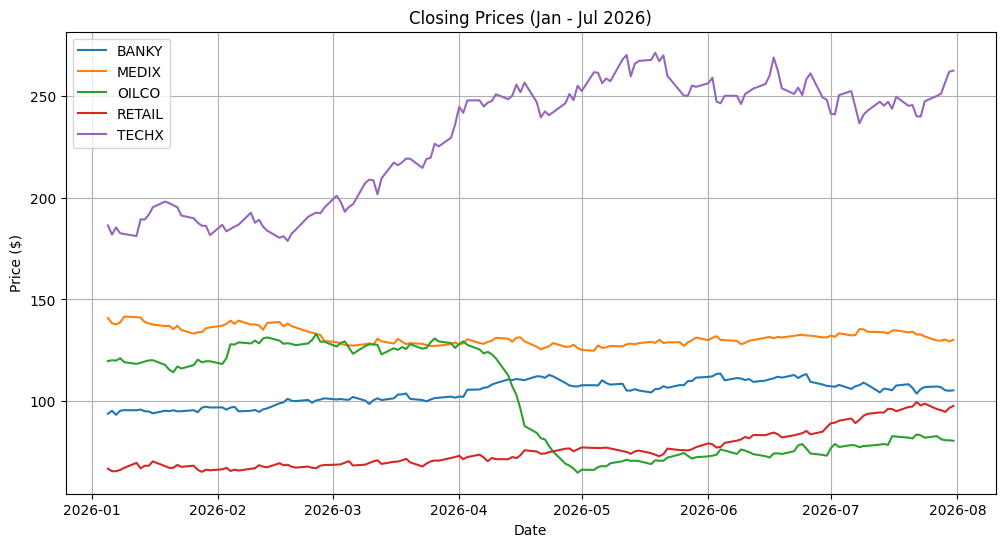

In [26]:
analyzer.plot_prices()

### Q21 · Growth of $100 (fair comparison)

Dividing each price by the stock's **first** price removes the different starting
levels ($185 vs $67) and shows pure performance.

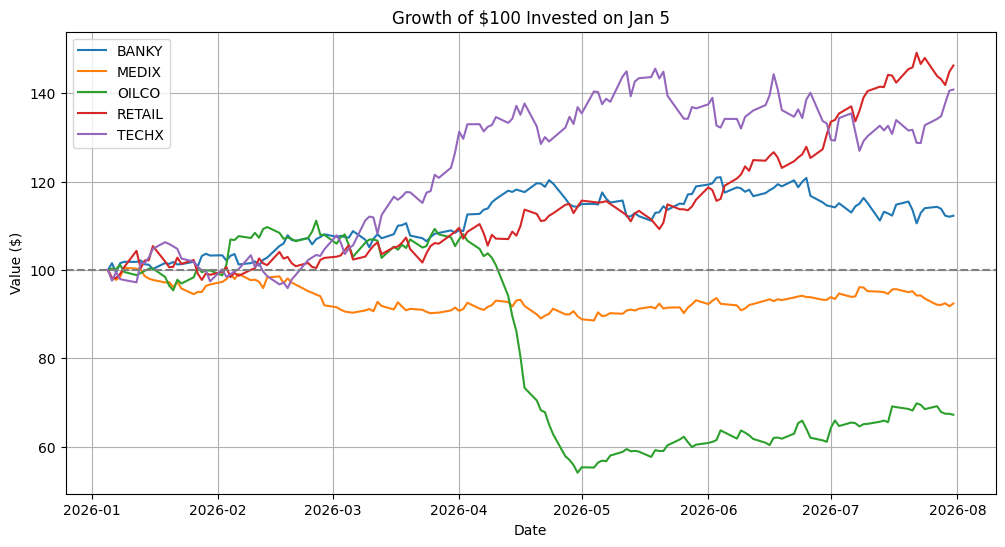

In [27]:
analyzer.plot_growth_of_100()

### Q22 · Histogram of OILCO returns

Look at the far-left tail — those bars far from the center are the crash days.

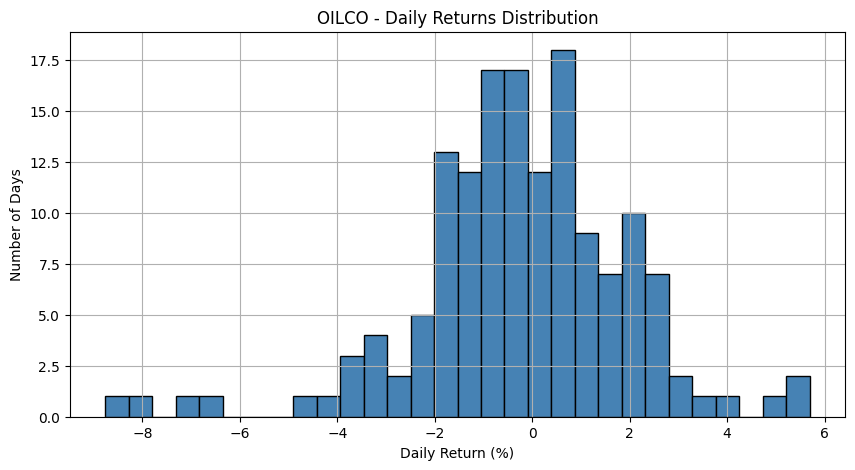

In [28]:
analyzer.plot_returns_histogram("OILCO")

### Q23 · Volume bar charts (per stock, then per sector)

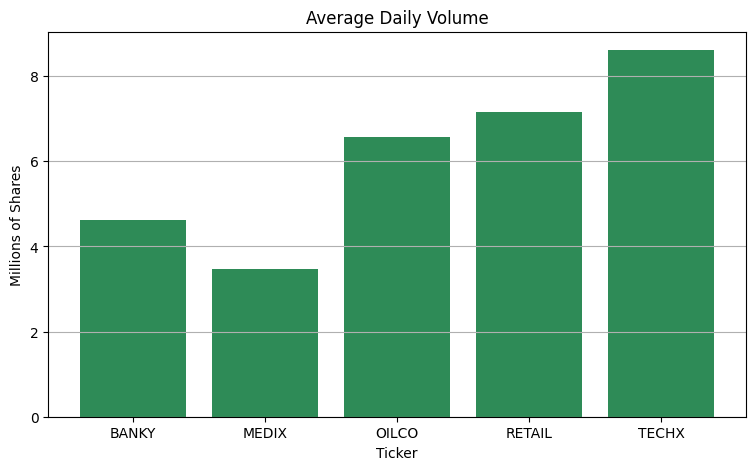

In [29]:
analyzer.plot_avg_volume()

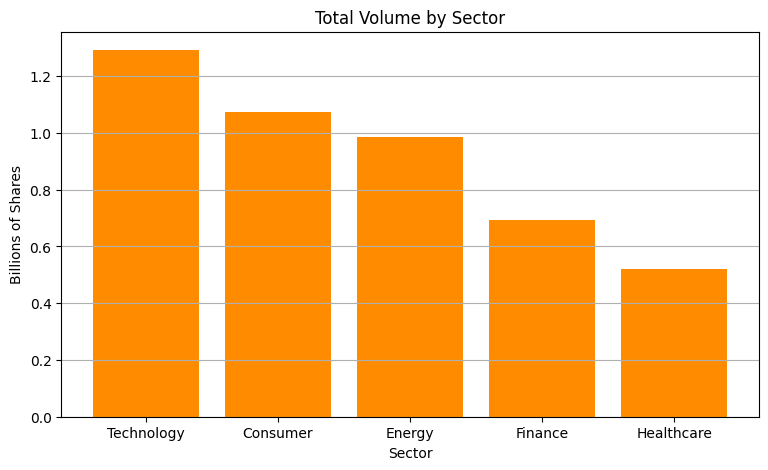

In [30]:
analyzer.plot_sector_volume()

### Q24 · Boxplot of daily returns

The box = middle 50% of days. Long whiskers/outliers = surprise days.
OILCO's box is widest — highest risk.

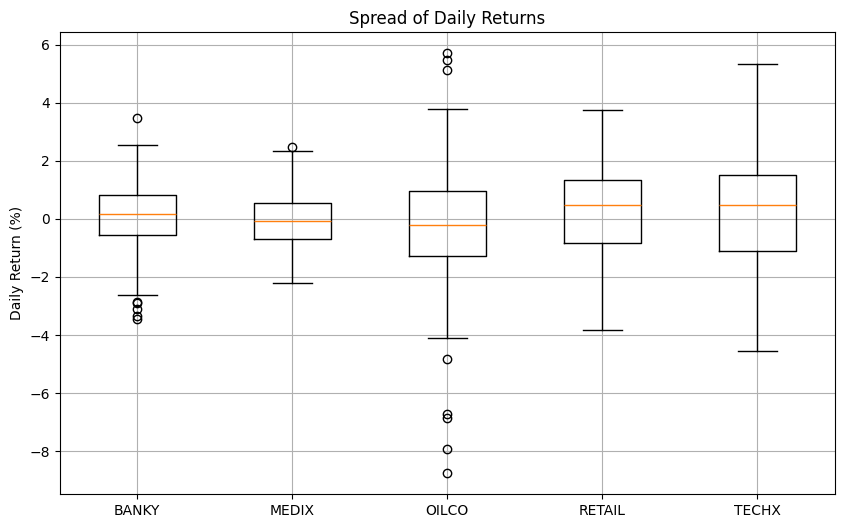

In [31]:
analyzer.plot_returns_boxplot()

### Q25 · Scatter: volume vs move size (TECHX)

Points drifting to the upper-right would confirm *big volume ↔ big move*.

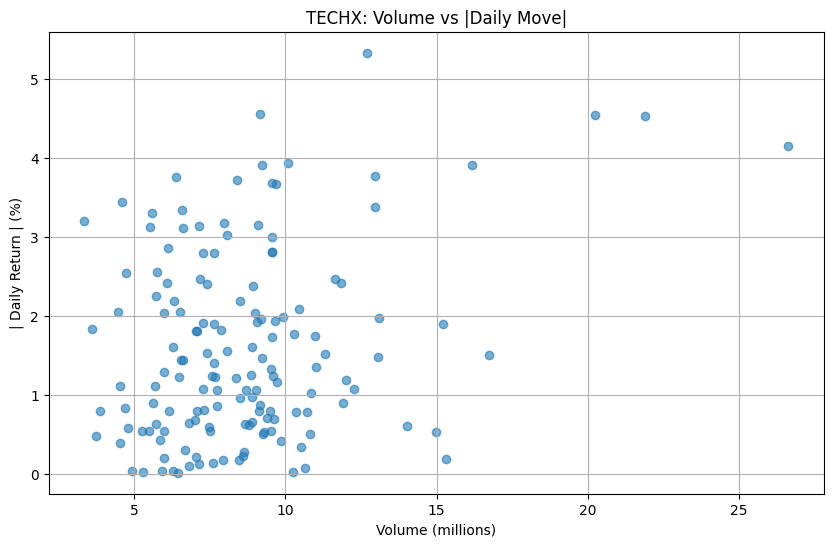

In [32]:
analyzer.plot_volume_vs_move("TECHX")

### Q26 · 2×3 subplot grid

`plt.subplots(2, 3)` hands us a grid of axes; we fill them one by one with a
counter that walks through the ticker list.

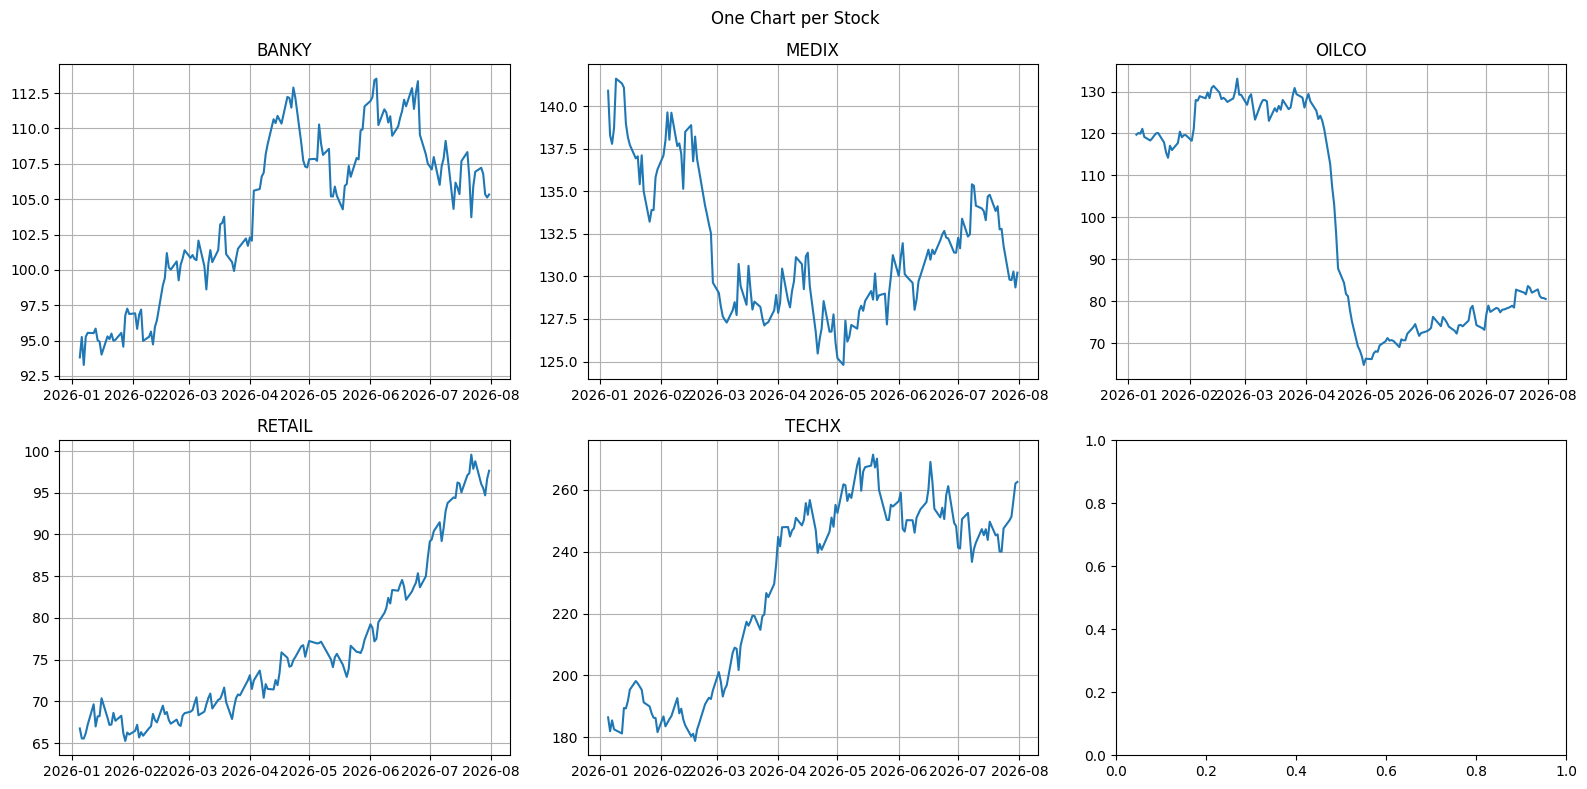

In [33]:
analyzer.plot_subplot_grid()

---
# ⭐ BONUS Challenges

### Q27 · Maximum drawdown per stock

Drawdown = how far the price fell **below its highest point so far**.
`cummax()` tracks that running record high; the worst value is the answer.

In [34]:
analyzer.max_drawdown_all()

BANKY | max drawdown: -8.6 % on 2026-07-22
MEDIX | max drawdown: -11.9 % on 2026-05-04
OILCO | max drawdown: -51.3 % on 2026-04-30
RETAIL | max drawdown: -7.3 % on 2026-01-28
TECHX | max drawdown: -12.8 % on 2026-07-08


### Q28 · Correlation heatmap of returns

First reshape prices into a wide table (`pivot`: dates as rows, tickers as columns),
convert to returns, then correlate. Warm colors = move together, cool = opposite.

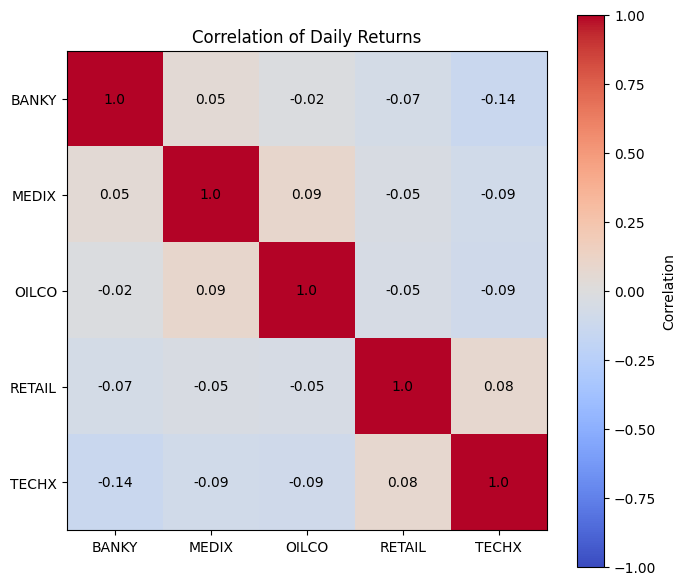

In [35]:
analyzer.plot_correlation_heatmap()

### Q29 · Dual-axis chart of OILCO

`twinx()` stacks a second y-axis on the same x-axis: blue price line left,
orange volume bars right, red dashed lines framing the June crash.

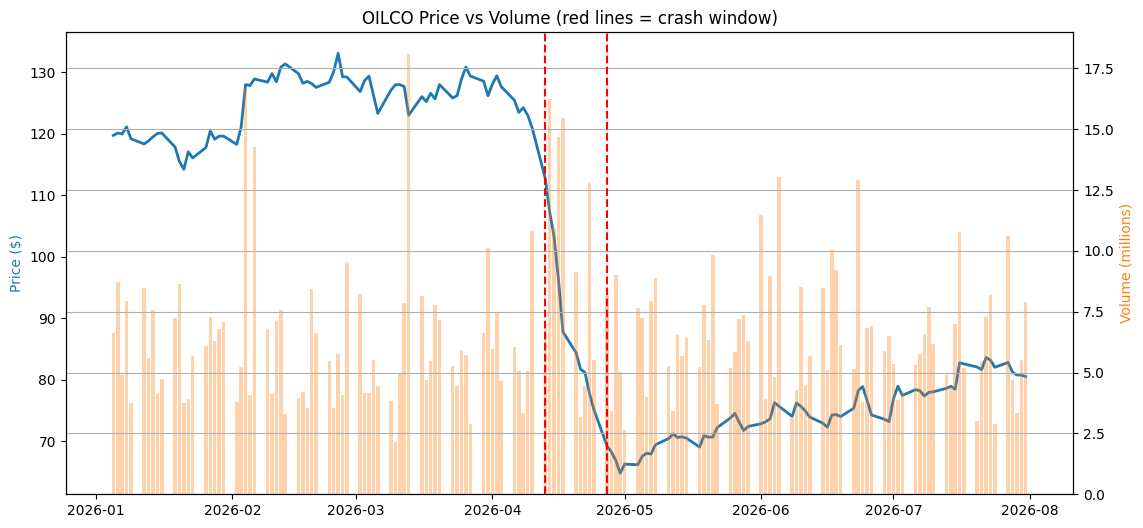

In [36]:
analyzer.plot_oilco_dual_axis()

### Q30 · Bollinger Bands (MEDIX)

Upper/lower bands sit 2 standard deviations around the 20-day MA.
When the black Close line pierces a band, the move is statistically extreme.

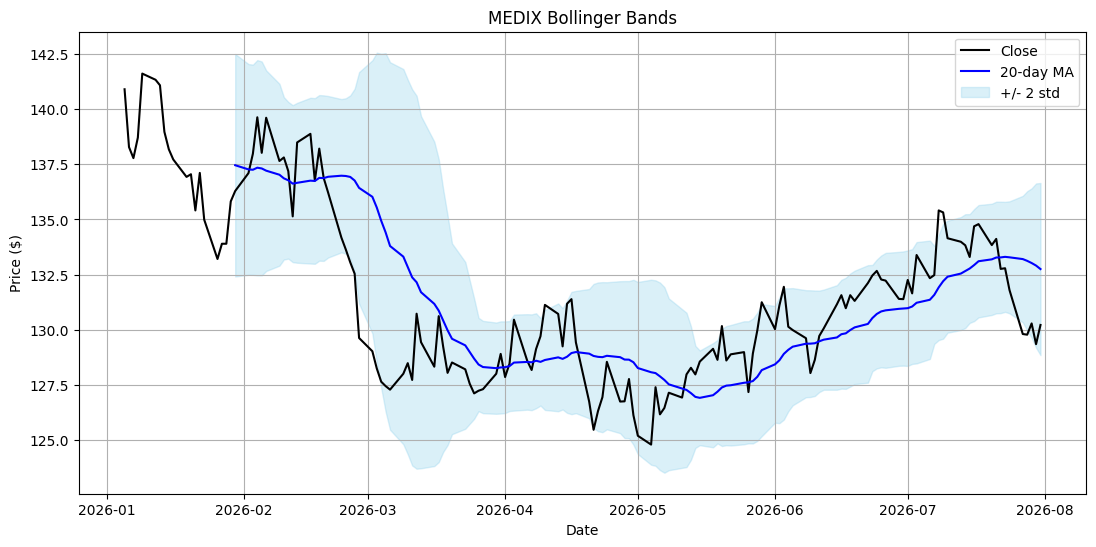

In [37]:
analyzer.plot_bollinger("MEDIX")

### Q31 · Safest two-stock portfolio

We test **all 10 pairs**. Each pair's risk uses the classic formula:

`risk = √(sd1² + sd2² + 2·ρ·sd1·sd2) / √2`

Low correlation (ρ) shrinks the total — that is diversification, visible in numbers.

In [38]:
analyzer.best_pair()

BANKY + MEDIX -> combined daily risk: 1.104 %
BANKY + OILCO -> combined daily risk: 1.763 %
BANKY + RETAIL -> combined daily risk: 1.339 %
BANKY + TECHX -> combined daily risk: 1.536 %
MEDIX + OILCO -> combined daily risk: 1.749 %
MEDIX + RETAIL -> combined daily risk: 1.25 %
MEDIX + TECHX -> combined daily risk: 1.494 %
OILCO + RETAIL -> combined daily risk: 1.858 %
OILCO + TECHX -> combined daily risk: 1.996 %
RETAIL + TECHX -> combined daily risk: 1.84 %

SAFEST PAIR: BANKY and MEDIX


---
# Key Takeaways

1. **Filter per stock** whenever you compute something sequential (`pct_change`, `shift`, `rolling`) — otherwise stocks bleed into each other.
2. `groupby` answers *"per ticker / per sector / per month"* questions in one line.
3. Normalized prices ($100 growth) make cross-stock comparisons honest.
4. OILCO crashed ~35% in June; its histogram tail and drawdown tell the story three different ways.
5. Combining low-correlated stocks (see Q28/Q31) genuinely reduces risk — diversification is not a myth.